# BO baseline #2 — closed-loop feedback policy

`01_bo_baseline_adapted_action.ipynb` optimises an **open-loop feed schedule**: BO picks one scale
factor per 25 h segment of the `Fs` recipe, and the batch then runs that profile no matter what the
process does. That is not the same *kind* of controller as MC-PILCO, so a head-to-head against it
confounds two differences at once — model-based vs model-free, **and** feedback vs no feedback.

This notebook removes the second one. BO here tunes the parameters of a **reactive feedback policy**
that observes the process at every decision step, exactly as MC-PILCO's learned policy does. The
only difference the comparison is meant to isolate is that MC-PILCO learns a dynamics model and
optimises its policy through it, while BO black-box-optimises a policy on real batches.

It is deliberately **not** an open-loop feed-sequence optimiser — that is what `01` already is, and
it is the design that reintroduces the dimensionality problem this one exists to avoid.

## How parity is enforced: reuse, not re-implementation

Every candidate policy runs through `PenSimWrapper.rollout()` — the *same* function
`02_/03_mcpilco_*_baseline.py` train with and `evaluations/eval_*_lib.py` evaluate with. `rollout`
accepts any `policy(state, decision_idx) -> action` callable, so a BO-parameterised policy drops
straight into the slot the trained RBF policy occupies.

| held identical to MC-PILCO | mechanism |
|---|---|
| simulator, episode length | `PenSimWrapper.rollout` -> `PenSimEnv`, 1150 native steps of 0.2 h |
| decision cadence | `T_SAMPLING = 5 h` -> 45 decisions per batch |
| action and its bound | one `Fs` action: `Fs = Fs_recipe * (1 + FS_SCALE * a)`, `a` clipped to `[-1, 1]`, `FS_SCALE = 0.5` |
| observed state | the normalised `STATE_NAMES` vector `extract_state` builds — nothing else is visible |
| measurement delay | inherited from `wrapper_par`; under `pms_visc_delay` **`rollout` itself** wraps the policy in `_ZOHPolicyProxy`, so the BO policy gets the held Viscosity automatically |
| reported metric | `eval_utils.yield_kg` / `feasibility_gated_yield_kg` — literally the numbers in `A1_held_out.csv` |
| held-out batches | `eval_base = 700000`, 5 seeds — the same block `eval_held_out()` uses |

Because none of the above is re-written here, this arm cannot silently drift away from the
MC-PILCO arm the way a hand-rolled copy of the rollout loop would.

## The three signed-off design decisions

1. **Policy class — affine state feedback, 6 parameters** (a bias plus one gain per observed
   channel). The minimum-assumption reactive controller: MC-PILCO's 100-basis RBF policy is a
   strict nonlinear superset of it, so BO is not handed any structure MC-PILCO had to discover for
   itself. See §3 for the exact form and bounds.
2. **Fit on the training block, report on held-out.** Candidate fitness is averaged over the same
   batch realisations MC-PILCO trains on (`seed*1000 + 0,1,2`); every reported number is measured
   on `700000-700004`, which the optimiser never sees. This is a deliberate reading of "score it
   the way MC-PILCO is scored": MC-PILCO's `A1` numbers are out-of-sample, so BO's must be too, or
   the comparison silently pits an in-sample number against an out-of-sample one.
3. **Budget — 3 batches/candidate x 60 calls x 1 BO seed = 180 batch-evaluations.** This is the
   fast setting chosen at sign-off. It is enough to see the shape of the anytime curve, but read
   the plateau diagnostic in §6 and the caveats in §10 before quoting the asymptotic best as
   converged.

In [1]:
import os, sys, re, time, json, contextlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.dirname(ROOT))

# Importing the real wrapper (instead of driving PenSimEnv.get_batches directly, as 01 does) is the
# whole point: it is what makes the action bound, the state encoding, the decision cadence and the
# optional measurement delay identical to the MC-PILCO arm by construction. It calls
# patch_fastodeint() at import time, so there is no separate patch call here.
import mcpilco.pensim_wrapper as pw
from mcpilco.pensim_wrapper import (PenSimWrapper, CONTROL_H, T_SAMPLING, STATE_NAMES,
                                    STATE_RANGES, FS_SCALE, VISC_MAX, WT_OVERFLOW,
                                    encode_state_value)
from experiments.eval_utils import yield_kg, feasibility_gated_yield_kg, constraint_diagnostics

from skopt import gp_minimize
from skopt.space import Real
from sklearn.exceptions import ConvergenceWarning

# sklearn's GP refits at every call and is chatty about near-singular kernels on a 6-D design with
# few points; the fit is still usable, and the noise term (see §5) is what handles the conditioning.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.gaussian_process.*")

N_DECISIONS = int(CONTROL_H / T_SAMPLING)
print(f"observed state : {STATE_NAMES}")
print(f"decisions      : {N_DECISIONS} x {T_SAMPLING} h  (CONTROL_H = {CONTROL_H} h)")
print(f"action         : Fs = Fs_recipe * (1 + {FS_SCALE} * a),  a in [-1, 1]")
print(f"envelope       : Viscosity <= {VISC_MAX} cP,  Wt <= {WT_OVERFLOW:g}")

observed state : ['Wt', 'X', 'P', 'Viscosity', 'time']
decisions      : 45 x 5 h  (CONTROL_H = 229.8 h)
action         : Fs = Fs_recipe * (1 + 0.5 * a),  a in [-1, 1]
envelope       : Viscosity <= 100.0 cP,  Wt <= 120000


## 1. Run identity — which MC-PILCO run is this the comparator for?

Point `MCPILCO_RUN` at the run you want to compare against. Its `note.txt` is parsed rather than
hand-copied, so the wrapper settings (`pms_visc_delay` / `use_offline_measurements`), the decision
interval and the interaction budget of the MC-PILCO arm all come from what that run *actually did*.

The seed mapping matters and is easy to get wrong: a run launched as `--seed 4` sets
`wrapper_par["seed_offset"] = 4000` and its training episode *e* runs on simulator seed `4000 + e`.
`--seed 4` is therefore **not** simulator seed 4 — the notebook `01` default. Fitting on
`4000, 4001, 4002` is what puts BO on the same batch realisations MC-PILCO learned from.

In [2]:
MCPILCO_RUN = Path("../results/dual_phase_baseline/seed4_13")   # <-- the run being compared against

_NOTE_DEFAULTS = {"seed": 4, "t_sampling": 5, "pms_visc_delay": False,
                  "use_offline_measurements": False, "num_explorations": 5, "num_trials": 10,
                  "num_high_feed_probes": 0}


def parse_note(run_dir):
    """Read the `== run parameters ==` block of a run's note.txt into a dict.

    Same idea as eval_single_phase_lib._build_cfg_kwargs: the run's own note is the authority on
    what it did, so parity settings are never re-typed here and cannot drift from the arm they are
    supposed to match. Falls back to _NOTE_DEFAULTS (loudly) if the run isn't on disk, so the
    notebook still runs standalone.
    """
    note = Path(run_dir) / "note.txt"
    if not note.exists():
        print(f"!! {note} not found -- falling back to defaults {_NOTE_DEFAULTS}")
        return dict(_NOTE_DEFAULTS), False
    out = dict(_NOTE_DEFAULTS)
    for line in note.read_text().splitlines():
        # the run-parameters block is flat `key = value`; stop before `== resolved config ==`,
        # whose pprint'd dict also contains `=` and would otherwise be parsed as parameters.
        if line.startswith("== resolved config"):
            break
        m = re.match(r"^(\w+) = (.*)$", line.strip())
        if m and m.group(1) in out:
            v = m.group(2)
            out[m.group(1)] = {"True": True, "False": False}.get(v, v)
    for k in ("seed", "num_explorations", "num_trials", "num_high_feed_probes"):
        out[k] = int(out[k])
    out["t_sampling"] = float(out["t_sampling"])
    return out, True


NOTE, NOTE_FOUND = parse_note(MCPILCO_RUN)

# A T_sampling mismatch would mean the two arms make a different NUMBER of decisions over the same
# batch -- not a fair comparison, and not fixable from inside this notebook (T_SAMPLING must be
# overridden via pensim_wrapper.set_t_sampling BEFORE the module is first imported). Fail loudly.
assert float(NOTE["t_sampling"]) == float(T_SAMPLING), (
    f"MC-PILCO run used t_sampling={NOTE['t_sampling']} but this process imported "
    f"T_SAMPLING={T_SAMPLING}; restart the kernel and call pw.set_t_sampling() before importing.")

TRAIN_SEED = NOTE["seed"]
SEED_OFFSET = TRAIN_SEED * 1000            # exactly config_*.get_config's wrapper_par seed_offset

# Same two Viscosity-delay switches the MC-PILCO run used, so the policy's inputs are degraded (or
# not) identically in both arms. Under pms_visc_delay, rollout wraps our policy in _ZOHPolicyProxy
# by itself -- nothing extra to do here.
WRAPPER_PAR = {"pms_visc_delay": NOTE["pms_visc_delay"],
               "use_offline_measurements": NOTE["use_offline_measurements"]}

# --- seed blocks -----------------------------------------------------------------------------
N_FIT_BATCHES = 3                                            # batches averaged per candidate
FIT_SEEDS = [SEED_OFFSET + i for i in range(N_FIT_BATCHES)]  # == MC-PILCO's own training batches

EVAL_BASE, N_TEST_BATCHES = 700000, 5                        # eval_single_phase_lib.eval_held_out
TEST_SEEDS = [EVAL_BASE + i for i in range(N_TEST_BATCHES)]

assert not (set(FIT_SEEDS) & set(TEST_SEEDS)), "fit and test blocks must be disjoint"

# --- BO budget -------------------------------------------------------------------------------
N_CALLS, N_RANDOM, BO_SEEDS = 60, 15, [0]
# heavier settings from the sign-off, if the plateau check in §6 says 60 calls was not enough:
# N_FIT_BATCHES, N_CALLS, N_RANDOM, BO_SEEDS = 3, 80, 15, [0, 1, 2]
# N_FIT_BATCHES, N_CALLS, N_RANDOM, BO_SEEDS = 5, 120, 20, [0, 1, 2]

# What the MC-PILCO arm spent, in the same currency: every episode it ran on the real simulator.
MCPILCO_BATCH_EVALS = NOTE["num_explorations"] + NOTE["num_trials"] + NOTE["num_high_feed_probes"]

print(f"MC-PILCO run  : {MCPILCO_RUN}  (note.txt {'parsed' if NOTE_FOUND else 'MISSING'})")
print(f"  --seed {TRAIN_SEED} -> seed_offset {SEED_OFFSET}, wrapper_par {WRAPPER_PAR}")
print(f"  budget: {NOTE['num_explorations']} explorations + {NOTE['num_trials']} trials"
      f" + {NOTE['num_high_feed_probes']} probes = {MCPILCO_BATCH_EVALS} real batches")
print(f"BO fit seeds  : {FIT_SEEDS}   (MC-PILCO's training realisations)")
print(f"BO test seeds : {TEST_SEEDS}  (never seen by the optimiser)")
print(f"BO budget     : {N_CALLS} calls x {N_FIT_BATCHES} batches x {len(BO_SEEDS)} BO seed(s)"
      f" = {N_CALLS * N_FIT_BATCHES * len(BO_SEEDS)} batch-evaluations")

MC-PILCO run  : ../results/dual_phase_baseline/seed4_13  (note.txt parsed)
  --seed 4 -> seed_offset 4000, wrapper_par {'pms_visc_delay': False, 'use_offline_measurements': False}
  budget: 5 explorations + 10 trials + 0 probes = 15 real batches
BO fit seeds  : [4000, 4001, 4002]   (MC-PILCO's training realisations)
BO test seeds : [700000, 700001, 700002, 700003, 700004]  (never seen by the optimiser)
BO budget     : 60 calls x 3 batches x 1 BO seed(s) = 180 batch-evaluations


## 2. The policy class (signed off) — affine state feedback, 6 parameters

$$a_t \;=\; \mathrm{clip}\!\Big(b + \sum_{c} w_c\, z_{c,t},\; -1,\; +1\Big),
\qquad F_{s,t} = F_{s,t}^{\text{recipe}} \cdot (1 + 0.5\, a_t)$$

where $z_t$ is **exactly** the vector `extract_state` hands MC-PILCO's policy: the observed channels
`Wt, X, P, Viscosity, time`, log-encoded where `STATE_LOG_CHANNELS` says so and then normalised to
$[-1,1]$ against `STATE_RANGES`. Nothing latent is readable — no substrate, no dissolved oxygen, no
CO₂ — so the policy is as deployable as MC-PILCO's, and no more.

**Why the gains are bounded at ±2 and the bias at ±1.** Because the inputs are already normalised,
the bounds are interpretable rather than arbitrary: a channel that traverses its whole
`STATE_RANGES` band swings $z$ by 2, so $|w_c| = 2$ is "this one channel alone can drive the action
from one rail to the other twice over" — comfortably past saturation, and wider is meaningless once
the clip binds. The bias spans the full action range by itself, which means **the class contains
every constant policy, including $a \equiv 0$: the untouched recipe.** BO therefore cannot do worse
than the recipe except by failing to search, and §4 asserts that the $\theta = 0$ member really does
reproduce the recipe batch bit-for-bit.

Time is included as an input on purpose. Without it an affine policy could not schedule at all, and
the comparison would be against a strawman; with it, this class strictly contains a linear-in-time
feed ramp — a fair chunk of what `01`'s 10-segment open-loop search was buying.

In [3]:
PARAM_NAMES = ["bias"] + [f"w_{n}" for n in STATE_NAMES]
PARAM_BOUNDS = [(-1.0, 1.0)] + [(-2.0, 2.0)] * len(STATE_NAMES)
N_PARAMS = len(PARAM_NAMES)


def affine_policy(theta):
    """theta -> a `policy(state, decision_idx) -> action` callable of the shape rollout() expects.

    `state` arrives already normalised to [-1, 1] (extract_state), and already Viscosity-held if
    the wrapper was built with pms_visc_delay -- rollout applies _ZOHPolicyProxy on the OUTSIDE of
    whatever callable it is given, so this function neither knows nor needs to know about the delay.

    The returned action is clipped here as well as inside rollout. That is not redundant: the clip
    is part of the policy's DEFINITION (the class is a saturating linear controller, not an
    unbounded one), and leaving it to the caller would make the parameterisation depend on where
    the saturation happens to live.
    """
    theta = np.asarray(theta, dtype=float).ravel()
    assert theta.size == N_PARAMS, f"expected {N_PARAMS} params, got {theta.size}"
    bias, gains = theta[0], theta[1:]

    def policy(state, decision_idx, bias=bias, gains=gains):
        return np.array([np.clip(bias + float(gains @ np.asarray(state, dtype=float)), -1.0, 1.0)])

    return policy


def describe_policy(theta):
    return "  ".join(f"{n}={v:+.3f}" for n, v in zip(PARAM_NAMES, np.asarray(theta).ravel()))


print(f"{N_PARAMS} search dimensions")
for n, (lo, hi) in zip(PARAM_NAMES, PARAM_BOUNDS):
    print(f"  {n:<14} [{lo:+.1f}, {hi:+.1f}]")

# The normalised value each channel takes at a few physical operating points, so the gain bounds
# above can be read in process units rather than in [-1, 1] abstractions.
_probe = {"Wt": [7e4, 1.1e5], "X": [5.0, 30.0], "P": [1.0, 30.0],
          "Viscosity": [40.0, VISC_MAX], "time": [50.0, 200.0]}
print("\nnormalised value of each observed channel at two physical operating points:")
for n in STATE_NAMES:
    lo, hi = STATE_RANGES[n]
    zs = [2.0 * (encode_state_value(n, v) - lo) / (hi - lo) - 1.0 for v in _probe[n]]
    print(f"  {n:<10} {_probe[n][0]:>9.4g} -> z={zs[0]:+.3f}   {_probe[n][1]:>9.4g} -> z={zs[1]:+.3f}")

6 search dimensions
  bias           [-1.0, +1.0]
  w_Wt           [-2.0, +2.0]
  w_X            [-2.0, +2.0]
  w_P            [-2.0, +2.0]
  w_Viscosity    [-2.0, +2.0]
  w_time         [-2.0, +2.0]

normalised value of each observed channel at two physical operating points:
  Wt             7e+04 -> z=-0.296     1.1e+05 -> z=+0.650
  X                  5 -> z=+0.378          30 -> z=+0.914
  P                  1 -> z=+0.095          30 -> z=+0.904
  Viscosity         40 -> z=-0.333         100 -> z=+0.667
  time              50 -> z=-0.565         200 -> z=+0.739


## 3. Batch evaluation, scoring, and the budget meter

**The objective is feasibility-gated yield.** `feasibility_gated_yield_kg` returns `yield_kg` for a
batch that stayed inside the operating envelope and **0 kg** for one that breached it (viscosity
over `VISC_MAX = 100 cP`, or `Wt` over `WT_OVERFLOW`). This is not decoration: the reward-hacking
probe in `evaluations/cost_reward_hacking_bo_results.md` found that two of four candidate reward
functions were driven by BO straight into viscosity collapse — 7/10 batches breaching, raw yield
still reading ~3,500 kg while envelope-valid yield fell to ~1,100 kg. An ungated objective here
would reproduce exactly that failure and report it as a win. Raw yield is still recorded alongside,
so the gap between the two is visible rather than hidden.

**Crashed batches are penalised, not dropped.** A candidate whose batch raises scores the same 0 kg
as an envelope breach and is counted in `n_failed`. Dropping them would let BO improve its mean by
finding parameter regions that break the simulator.

**What the gate can and cannot do.** It is applied to the batches BO actually measures, so it can
only reject a policy whose breach *shows up on the fit block*. One that stays just under `VISC_MAX`
on those batches and crosses on others is still selected. A smoke run of this notebook at one fit
batch produced exactly that: the winner scored 3,959 kg with no breach on its single fit batch, then
came in at 1,566 kg gated on held-out with 3/5 batches breaching and viscosity peaking at 184 cP.
Averaging over more fit batches makes the gate bite harder; it never makes it airtight. That is why
§6 reports the held-out breach count and the raw-vs-gated gap rather than the gated number alone.

**The budget meter separates the two kinds of batch.** `search` batches are the interaction budget —
the currency of the data-efficiency comparison. `measurement` batches (sanity checks, the recipe
reference, held-out scoring) are the *readout*, and are not charged to it, exactly as MC-PILCO's own
`A1` evaluation batches are not counted against its 15 training episodes.

In [4]:
WRAPPER = PenSimWrapper(**WRAPPER_PAR)

BUDGET = {"search": 0, "measurement": 0}
FAILED_SCORE_KG = 0.0
FAILURES = []


def run_batch(theta, seed, kind, pid_baseline=False):
    """One batch under `theta` (or the untouched recipe if pid_baseline). Returns a monitor or None.

    The monitor is POPPED off WRAPPER.monitor rather than left there: rollout appends one dict of
    nine 1150-long arrays per call, and a full search plus its readout is several hundred batches.
    """
    assert kind in BUDGET
    BUDGET[kind] += 1
    n_before = len(WRAPPER.monitor)
    try:
        WRAPPER.rollout(None, None if pid_baseline else affine_policy(theta),
                        CONTROL_H, T_SAMPLING, 0, seed=int(seed), pid_baseline=pid_baseline)
    except Exception as exc:                       # noqa: BLE001 - any failure scores, none escape
        del WRAPPER.monitor[n_before:]
        FAILURES.append({"seed": int(seed), "theta": np.asarray(theta).tolist(),
                         "error": f"{type(exc).__name__}: {exc}"})
        return None
    return WRAPPER.monitor.pop()


def score(theta, seeds, kind):
    """Mean feasibility-gated yield (kg) over `seeds` -- the fitness BO maximises.

    Averaging over several batch realisations is what stops a candidate from winning on one lucky
    batch: the same single-search-seed overfitting cost_reward_hacking_bo.py's docstring records as
    its problem (1), where an in-search 4,198 kg point validated at 3,640 +/- 1,093 kg elsewhere.
    """
    gated, raw, visc, wt, breaches, failed = [], [], [], [], 0, 0
    for s in seeds:
        mon = run_batch(theta, s, kind)
        if mon is None:
            failed += 1
            gated.append(FAILED_SCORE_KG)
            raw.append(FAILED_SCORE_KG)
            continue
        y = yield_kg(mon)
        if not np.isfinite(y):                     # a non-finite yield is a failure, not a score
            failed += 1
            gated.append(FAILED_SCORE_KG)
            raw.append(FAILED_SCORE_KG)
            continue
        d = constraint_diagnostics(mon)
        gated.append(feasibility_gated_yield_kg(mon))
        raw.append(y)
        visc.append(d["max_viscosity"])
        wt.append(d["max_Wt"])
        breaches += bool(d["visc_exceed"] or d["wt_overflow"])
    return {"mean_gated": float(np.mean(gated)), "mean_raw": float(np.mean(raw)),
            "sem_gated": float(np.std(gated, ddof=1) / np.sqrt(len(gated))) if len(gated) > 1 else 0.0,
            "max_visc": float(np.max(visc)) if visc else np.nan,
            "max_wt": float(np.max(wt)) if wt else np.nan,
            "n_breach": int(breaches), "n_failed": int(failed),
            "per_seed_gated": [float(v) for v in gated]}


def recipe_reference(seeds):
    """Untouched-recipe yield on `seeds` -- the same pid_baseline arm eval_held_out reports."""
    ys = [yield_kg(run_batch(None, s, "measurement", pid_baseline=True)) for s in seeds]
    return float(np.mean(ys)), [float(y) for y in ys]

## 4. Parity checks

Three things must hold before any search result is worth reading, and all three are cheap:

1. **`theta = 0` reproduces the recipe exactly.** The zero policy emits `a = 0`, so
   `Fs = Fs_recipe * (1 + 0.5*0)`. If that batch is not bit-identical to a `pid_baseline=True` run
   on the same seed, then something other than the action differs between the two arms and every
   comparison below is contaminated. Asserted, not just printed.
2. **The recipe reference on both seed blocks**, so the fit-block and test-block numbers can each
   be read against their own baseline (the blocks are different batch realisations and their recipe
   yields genuinely differ).
3. **Test-block recipe yield matches the MC-PILCO run's own `yield_recipe` column**, which is the
   end-to-end proof that this notebook and `A1_held_out.csv` are measuring the same batches with the
   same metric.

In [5]:
_t0 = time.time()

# --- 1. the zero member of the policy class is the recipe ------------------------------------
_m_pid = run_batch(None, FIT_SEEDS[0], "measurement", pid_baseline=True)
_m_zero = run_batch(np.zeros(N_PARAMS), FIT_SEEDS[0], "measurement")
_y_pid, _y_zero = yield_kg(_m_pid), yield_kg(_m_zero)
assert abs(_y_zero - _y_pid) < 1e-9, f"zero policy is not the recipe: {_y_zero} vs {_y_pid}"
assert np.allclose(_m_pid["Fs"], _m_zero["Fs"]), "zero policy perturbs the feed trajectory"
print(f"[1] theta=0 == recipe on seed {FIT_SEEDS[0]}: {_y_zero:.6f} kg "
      f"(diff {_y_zero - _y_pid:.2e}, Fs trajectories identical)")

# --- 2. recipe reference on both blocks -------------------------------------------------------
RECIPE_FIT, _fit_each = recipe_reference(FIT_SEEDS)
RECIPE_TEST, _test_each = recipe_reference(TEST_SEEDS)
print(f"[2] recipe on fit  block {FIT_SEEDS}: mean {RECIPE_FIT:8.1f} kg  "
      f"({', '.join(f'{v:.0f}' for v in _fit_each)})")
print(f"    recipe on test block {TEST_SEEDS}: mean {RECIPE_TEST:8.1f} kg  "
      f"({', '.join(f'{v:.0f}' for v in _test_each)})")

# --- 3. cross-check against the MC-PILCO run's own held-out table ------------------------------
A1 = MCPILCO_RUN / "A1_held_out.csv"
if A1.exists():
    _a1 = pd.read_csv(A1)
    _mine = pd.Series(_test_each, index=TEST_SEEDS)
    _theirs = _a1.set_index("seed")["yield_recipe"].reindex(TEST_SEEDS)
    _dev = float(np.nanmax(np.abs(_mine - _theirs)))
    print(f"[3] vs {A1.name}: max |diff| on the recipe arm = {_dev:.2e} kg "
          f"-> {'IDENTICAL batches and metric' if _dev < 1e-6 else '!! MISMATCH, investigate'}")
else:
    print(f"[3] {A1} not found -- skipping the cross-check against the MC-PILCO arm")

print(f"\nparity checks used {BUDGET['measurement']} measurement batches "
      f"in {time.time() - _t0:.0f}s (search budget still {BUDGET['search']})")

[1] theta=0 == recipe on seed 4000: 3314.304540 kg (diff 0.00e+00, Fs trajectories identical)


[2] recipe on fit  block [4000, 4001, 4002]: mean   3340.9 kg  (3314, 3510, 3199)
    recipe on test block [700000, 700001, 700002, 700003, 700004]: mean   3495.8 kg  (3467, 3574, 3697, 3527, 3215)
[3] vs A1_held_out.csv: max |diff| on the recipe arm = 0.00e+00 kg -> IDENTICAL batches and metric

parity checks used 10 measurement batches in 67s (search budget still 0)


## 5. The BO search

Standard GP-surrogate BO (`skopt.gp_minimize`) with Expected Improvement. Two settings differ from
`01` and both are deliberate:

- **`noise="gaussian"`, not `noise=1e-10`.** Each fitness is a 3-batch mean of a quantity whose
  batch-to-batch spread runs to hundreds of kg, so it is genuinely noisy. `01` declares the
  objective all but noiseless, which forces the GP to interpolate every point exactly — it then
  chases noise spikes and over-trusts single lucky evaluations. Here the surrogate fits a noise
  level and the posterior mean is free to smooth.
- **`random_state` is the BO seed, not the batch seed.** In `01` the same integer served as both
  the simulator realisation and the search seed, so "seed" confounded two independent sources of
  variation. They are separate here: batch realisations are fixed by `FIT_SEEDS`, and `BO_SEEDS`
  varies only the optimiser.

A note on RNG hygiene: `rollout(seed=...)` calls `np.random.seed()` on every batch, so the global
NumPy RNG is reset constantly during the search. `gp_minimize` is driven by its own `random_state`
and is unaffected — but nothing else in this notebook should rely on the global RNG.

*Non-stationarity caveat:* a bioprocess response surface is not stationary — the penalty cliff where
viscosity crosses `VISC_MAX` is a near-discontinuity, while the interior is smooth and gently
sloped. A single stationary Matérn kernel has to compromise between the two, typically by picking a
short lengthscale that under-smooths the interior. §6's plateau diagnostic is the practical check on
whether that hurt this search.

In [6]:
SPACE = [Real(lo, hi, name=n) for n, (lo, hi) in zip(PARAM_NAMES, PARAM_BOUNDS)]

runs = {}          # bo_seed -> DataFrame, one row per BO call
for bo_seed in BO_SEEDS:
    log = []

    def objective(x, _log=log):
        r = score(np.asarray(x, dtype=float), FIT_SEEDS, "search")
        _log.append({"call": len(_log) + 1, "batch_evals": (len(_log) + 1) * N_FIT_BATCHES,
                     **{k: v for k, v in r.items() if k != "per_seed_gated"},
                     **dict(zip(PARAM_NAMES, np.asarray(x, dtype=float)))})
        return -r["mean_gated"]                      # gp_minimize minimises; we want max yield

    t0 = time.time()
    res = gp_minimize(objective, SPACE, n_calls=N_CALLS, n_initial_points=N_RANDOM,
                      acq_func="EI", noise="gaussian", random_state=bo_seed)
    runs[bo_seed] = pd.DataFrame(log)
    d = runs[bo_seed]
    # skopt's own best and ours must agree: the anytime curve and the reported best are both read
    # off `log`, so a bug in it would otherwise be invisible.
    assert abs(-res.fun - d["mean_gated"].max()) < 1e-6, "log disagrees with gp_minimize's result"
    print(f"BO seed {bo_seed}: {N_CALLS} calls in {time.time() - t0:.0f}s | "
          f"best fit-block gated {d['mean_gated'].max():.1f} kg "
          f"(recipe {RECIPE_FIT:.1f}) | breaching evaluations "
          f"{int((d['n_breach'] > 0).sum())}/{N_CALLS} | failed batches {int(d['n_failed'].sum())}")

print(f"\nsearch budget consumed: {BUDGET['search']} batch-evaluations")
if FAILURES:
    print(f"!! {len(FAILURES)} batch(es) failed and were scored {FAILED_SCORE_KG} kg, not dropped:")
    for f in FAILURES[:5]:
        print(f"   seed {f['seed']}: {f['error']}")

BO seed 0: 60 calls in 1180s | best fit-block gated 3985.3 kg (recipe 3340.9) | breaching evaluations 2/60 | failed batches 0

search budget consumed: 180 batch-evaluations


## 6. Anytime curve on held-out batches, and the plateau check

The anytime curve answers "what would BO have handed you if you had stopped it after *b* batches?"
So at each checkpoint we take the best-so-far candidate **by fit-block fitness** (the only thing an
honest optimiser could select on) and score *that* policy on the five held-out batches. Held-out
evaluations are cached by parameter vector, because the best-so-far usually does not move between
consecutive checkpoints.

The plateau diagnostic follows the convention `cost_reward_hacking_bo.py` uses: how much the
held-out best-so-far still moves over the **last 20 %** of the budget. Small movement means the
reported asymptotic best is a converged number rather than an artefact of a truncated search.

In [7]:
_heldout_cache = {}


def heldout(theta):
    key = tuple(np.round(np.asarray(theta, dtype=float), 10))
    if key not in _heldout_cache:
        _heldout_cache[key] = score(np.asarray(theta), TEST_SEEDS, "measurement")
    return _heldout_cache[key]


CHECKPOINTS = list(range(N_RANDOM, N_CALLS + 1, 5))
anytime = {}
for bo_seed, d in runs.items():
    rows = []
    for b in CHECKPOINTS:
        k = d["mean_gated"].iloc[:b].idxmax()            # best-so-far by FIT fitness only
        th = d.loc[k, PARAM_NAMES].to_numpy(dtype=float)
        h = heldout(th)
        rows.append({"call": b, "batch_evals": b * N_FIT_BATCHES,
                     "fit_gated": float(d.loc[k, "mean_gated"]),
                     "heldout_gated": h["mean_gated"], "heldout_raw": h["mean_raw"],
                     "heldout_sem": h["sem_gated"], "heldout_breach": h["n_breach"],
                     "heldout_max_visc": h["max_visc"]})
    anytime[bo_seed] = pd.DataFrame(rows)

ANYTIME = pd.concat([a.assign(bo_seed=s) for s, a in anytime.items()], ignore_index=True)
display(ANYTIME.round(1))

# --- asymptotic best + plateau diagnostic ------------------------------------------------------
BEST = {}
for bo_seed, d in runs.items():
    k = d["mean_gated"].idxmax()
    th = d.loc[k, PARAM_NAMES].to_numpy(dtype=float)
    BEST[bo_seed] = {"theta": th, "fit": float(d.loc[k, "mean_gated"]), "heldout": heldout(th)}

print()
for bo_seed, b in BEST.items():
    a = anytime[bo_seed]
    tail = a[a["batch_evals"] >= 0.8 * a["batch_evals"].max()]["heldout_gated"]
    move = 100.0 * (tail.max() - tail.min()) / max(tail.max(), 1e-9)
    # A flat anytime curve has TWO very different causes and the movement figure alone cannot tell
    # them apart: the search converged, or it never improved on its own random initialisation. If
    # the winning call predates the EI phase, the flat tail means the acquisition function found
    # nothing in n_calls - n_random attempts -- a STALLED search, and reporting that as
    # "plateaued/converged" would overstate what the budget established.
    k_best = int(d["mean_gated"].idxmax()) + 1
    stalled = k_best <= N_RANDOM
    print(f"BO seed {bo_seed}")
    print(f"  best params      : {describe_policy(b['theta'])}")
    print(f"  fit-block gated  : {b['fit']:8.1f} kg   (recipe {RECIPE_FIT:.1f})")
    print(f"  HELD-OUT gated   : {b['heldout']['mean_gated']:8.1f} +/- {b['heldout']['sem_gated']:.1f} kg"
          f"   (recipe {RECIPE_TEST:.1f}, {100*(b['heldout']['mean_gated']-RECIPE_TEST)/RECIPE_TEST:+.2f}%)")
    print(f"  HELD-OUT raw     : {b['heldout']['mean_raw']:8.1f} kg"
          f"   (gap to gated = {b['heldout']['mean_raw'] - b['heldout']['mean_gated']:.1f} kg"
          f" -> {b['heldout']['n_breach']}/{N_TEST_BATCHES} breaching batches)")
    print(f"  max viscosity    : {b['heldout']['max_visc']:.1f} cP  (limit {VISC_MAX})")
    print(f"  best found at    : call {k_best} of {N_CALLS}"
          + (f"  <-- DURING RANDOM INIT (first {N_RANDOM}); the {N_CALLS - N_RANDOM} EI calls that"
             " followed never beat it" if stalled else "  (i.e. in the EI phase)"))
    print(f"  plateau check    : held-out best-so-far moved {move:.2f}% over the last 20% of budget"
          f" -> {'FLAT' if move < 1.0 else 'STILL MOVING: raise N_CALLS before quoting this'}")
    if move < 1.0 and stalled:
        print("                     ^ STALLED, NOT CONVERGED: the curve is flat because the best "
              "point came from\n                       random sampling and EI never improved on it. "
              "This is NOT evidence the\n                       asymptotic best is BO's ceiling -- "
              "see the non-stationarity note in §5.")
    elif move < 1.0:
        print("                     ^ converged: the best point came from the EI phase and the "
              "curve then settled.")

,call,batch_evals,fit_gated,heldout_gated,heldout_raw,heldout_sem,heldout_breach,heldout_max_visc,bo_seed
0,15,45,3985.3,3196.8,3483.6,806.8,1,155.4,0
1,20,60,3985.3,3196.8,3483.6,806.8,1,155.4,0
2,25,75,3985.3,3196.8,3483.6,806.8,1,155.4,0
3,30,90,3985.3,3196.8,3483.6,806.8,1,155.4,0
4,35,105,3985.3,3196.8,3483.6,806.8,1,155.4,0
5,40,120,3985.3,3196.8,3483.6,806.8,1,155.4,0
6,45,135,3985.3,3196.8,3483.6,806.8,1,155.4,0
7,50,150,3985.3,3196.8,3483.6,806.8,1,155.4,0
8,55,165,3985.3,3196.8,3483.6,806.8,1,155.4,0
9,60,180,3985.3,3196.8,3483.6,806.8,1,155.4,0



BO seed 0
  best params      : bias=+0.270  w_Wt=+1.981  w_X=+0.327  w_P=-0.343  w_Viscosity=-0.101  w_time=+0.494
  fit-block gated  :   3985.3 kg   (recipe 3340.9)
  HELD-OUT gated   :   3196.8 +/- 806.8 kg   (recipe 3495.8, -8.55%)
  HELD-OUT raw     :   3483.6 kg   (gap to gated = 286.8 kg -> 1/5 breaching batches)
  max viscosity    : 155.4 cP  (limit 100.0)
  best found at    : call 10 of 60  <-- DURING RANDOM INIT (first 15); the 45 EI calls that followed never beat it
  plateau check    : held-out best-so-far moved 0.00% over the last 20% of budget -> FLAT
                     ^ STALLED, NOT CONVERGED: the curve is flat because the best point came from
                       random sampling and EI never improved on it. This is NOT evidence the
                       asymptotic best is BO's ceiling -- see the non-stationarity note in §5.


## 7. Plots — data efficiency and the search trace

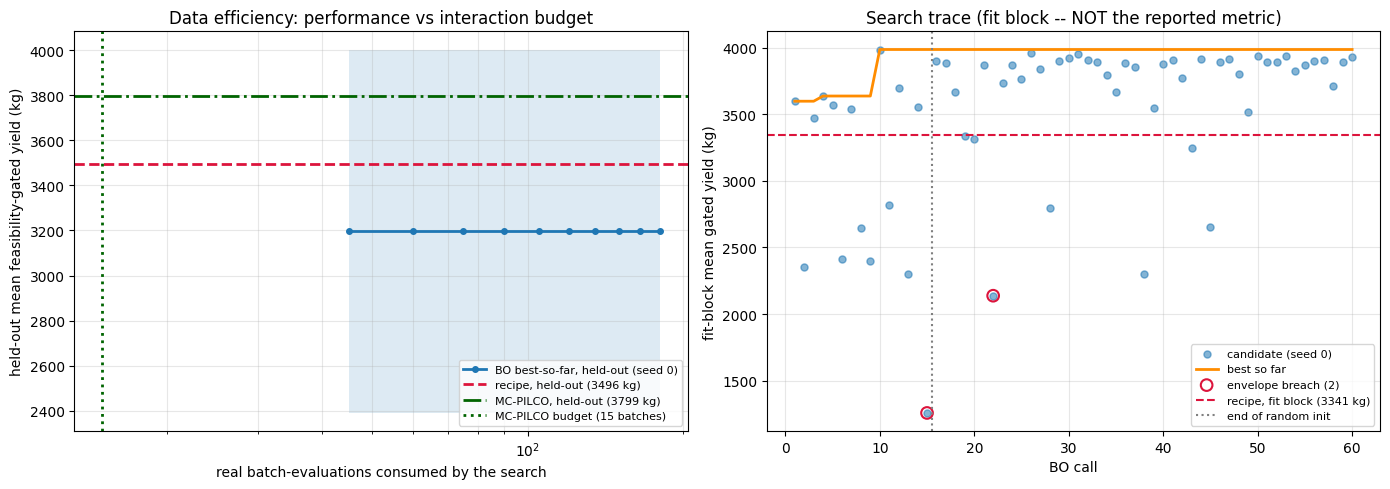

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- left: the data-efficiency comparison ------------------------------------------------------
for bo_seed, a in anytime.items():
    ax[0].plot(a["batch_evals"], a["heldout_gated"], "o-", lw=2, ms=4,
               label=f"BO best-so-far, held-out (seed {bo_seed})")
    ax[0].fill_between(a["batch_evals"], a["heldout_gated"] - a["heldout_sem"],
                       a["heldout_gated"] + a["heldout_sem"], alpha=.15)
ax[0].axhline(RECIPE_TEST, color="crimson", ls="--", lw=2,
              label=f"recipe, held-out ({RECIPE_TEST:.0f} kg)")

A1 = MCPILCO_RUN / "A1_held_out.csv"
if A1.exists():
    _a1 = pd.read_csv(A1)
    _mc = float(_a1["yield_rl"].mean())
    ax[0].axhline(_mc, color="darkgreen", ls="-.", lw=2,
                  label=f"MC-PILCO, held-out ({_mc:.0f} kg)")
    ax[0].axvline(MCPILCO_BATCH_EVALS, color="darkgreen", ls=":", lw=2,
                  label=f"MC-PILCO budget ({MCPILCO_BATCH_EVALS} batches)")

ax[0].set(xlabel="real batch-evaluations consumed by the search",
          ylabel="held-out mean feasibility-gated yield (kg)",
          title="Data efficiency: performance vs interaction budget")
ax[0].set_xscale("log")
ax[0].legend(fontsize=8, loc="lower right")
ax[0].grid(alpha=.3, which="both")

# --- right: the raw search trace ---------------------------------------------------------------
for bo_seed, d in runs.items():
    ax[1].scatter(d["call"], d["mean_gated"], s=26, alpha=.55, label=f"candidate (seed {bo_seed})")
    ax[1].plot(d["call"], d["mean_gated"].cummax(), lw=2, color="darkorange", label="best so far")
    br = d[d["n_breach"] > 0]
    if len(br):
        ax[1].scatter(br["call"], br["mean_gated"], s=70, facecolors="none", edgecolors="crimson",
                      lw=1.5, label=f"envelope breach ({len(br)})")
ax[1].axhline(RECIPE_FIT, color="crimson", ls="--", label=f"recipe, fit block ({RECIPE_FIT:.0f} kg)")
ax[1].axvline(N_RANDOM + .5, color="grey", ls=":", label="end of random init")
ax[1].set(xlabel="BO call", ylabel="fit-block mean gated yield (kg)",
          title="Search trace (fit block -- NOT the reported metric)")
ax[1].legend(fontsize=8, loc="lower right")
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 8. What the winning policy actually does — including the CO₂ excursion check

The brief asks for a flag if BO finds policies that exploit or trigger the documented CO₂ inhibition
excursions. `rollout`'s monitor does not carry `CO2outgas` or substrate `S`, and no repo file is
modified here, so those two channels are captured by temporarily swapping `pensim_wrapper.PenSimEnv`
for a tracing subclass **inside a context manager**, for the diagnostic batch only. The swap is
notebook-local and reverted on exit; the simulation itself is untouched (`super().step` does all the
work), so the traced batch is the same batch that would have run anyway.

Substrate `S` is traced alongside CO₂ because it is the upstream cause: `STATE_RANGES`'s own comment
records that `S` sits near zero (median ~1.6e-3 g/L) but spikes to ~14 g/L under overfeeding, and
that spike is the accumulation warning that precedes a crash.

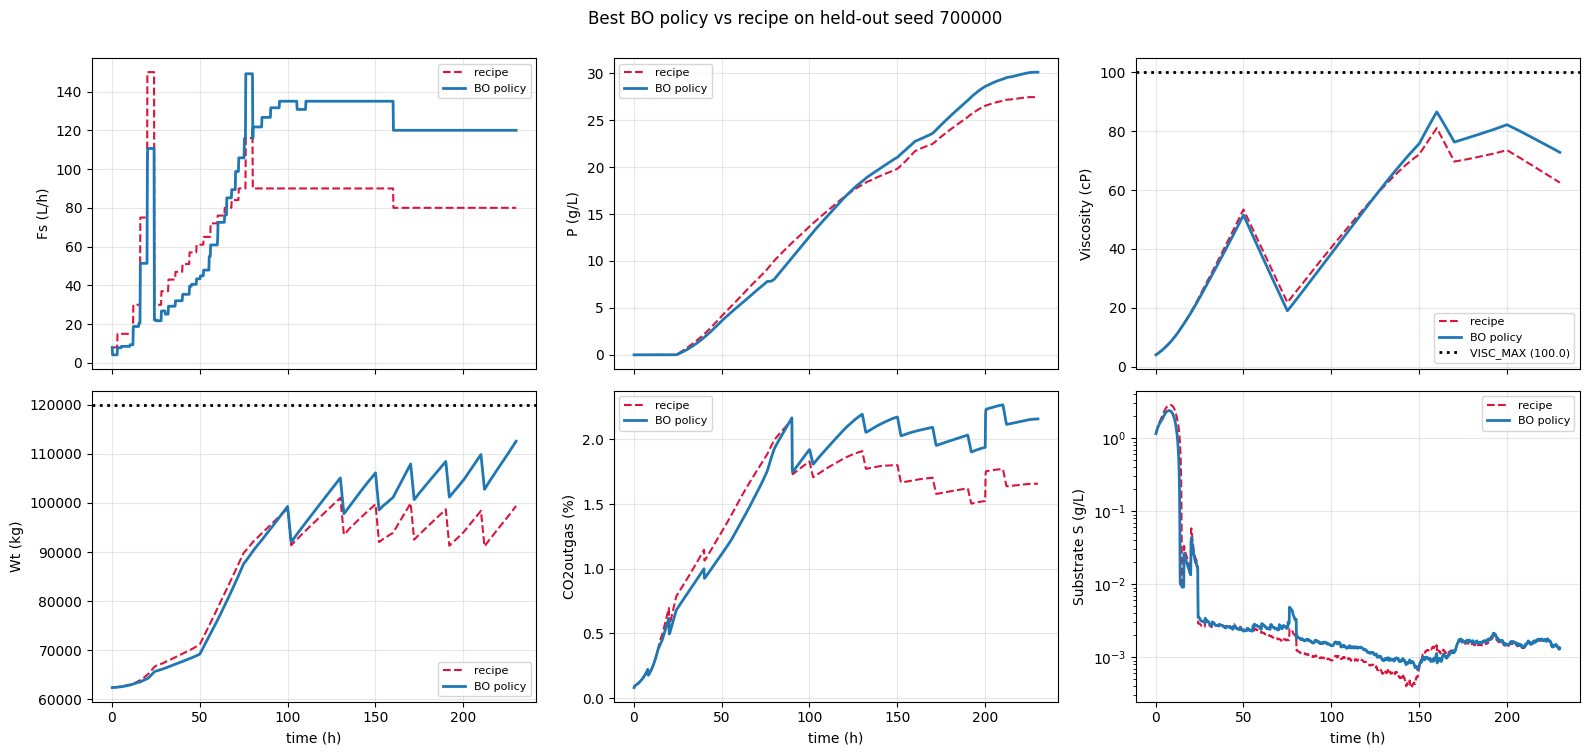

held-out seed 700000: yield BO 4100.6 kg vs recipe 3467.3 kg
  max Viscosity : BO   86.5 cP  recipe   81.0 cP   (limit 100.0; breach: BO False, recipe False)
  max Wt        : BO    112584     recipe    101050   (limit 120000)
  max CO2outgas : BO  2.266 %   recipe  2.147 %   (+5.5% vs recipe)
  max substrate : BO  2.398 g/L recipe  2.873 g/L   (0.83x recipe)

no CO2 / substrate excursion flag: the winning policy stays within recipe-like ranges.


In [9]:
_TRACE = {}


class _TracingEnv(pw.PenSimEnv):
    """PenSimEnv that also records unmonitored batch channels. Simulation logic is untouched."""

    def step(self, k, x, *args, **kwargs):
        out = super().step(k, x, *args, **kwargs)
        bx = out[1]
        for ch in _TRACE:
            _TRACE[ch].append(float(getattr(bx, ch).y[k - 1]))
        return out


@contextlib.contextmanager
def trace_channels(channels):
    """Temporarily make rollout build a tracing env. Notebook-local; no repo file is modified."""
    _TRACE.clear()
    _TRACE.update({c: [] for c in channels})
    original = pw.PenSimEnv
    pw.PenSimEnv = _TracingEnv
    try:
        yield _TRACE
    finally:
        pw.PenSimEnv = original


BEST_SEED = max(BEST, key=lambda s: BEST[s]["heldout"]["mean_gated"])
BEST_THETA = BEST[BEST_SEED]["theta"]
DIAG_SEED = TEST_SEEDS[0]

with trace_channels(["CO2outgas", "S"]) as tr:
    mon_bo = run_batch(BEST_THETA, DIAG_SEED, "measurement")
    co2, S = np.array(tr["CO2outgas"]), np.array(tr["S"])
with trace_channels(["CO2outgas", "S"]) as tr:
    mon_rec = run_batch(None, DIAG_SEED, "measurement", pid_baseline=True)
    co2_rec, S_rec = np.array(tr["CO2outgas"]), np.array(tr["S"])

assert pw.PenSimEnv is not _TracingEnv, "tracing env leaked out of the context manager"

t = mon_bo["t"]
fig, ax = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True)
for a, key, lab in [(ax[0][0], "Fs", "Fs (L/h)"), (ax[0][1], "P", "P (g/L)"),
                    (ax[0][2], "Viscosity", "Viscosity (cP)"), (ax[1][0], "Wt", "Wt (kg)")]:
    a.plot(t, mon_rec[key], color="crimson", ls="--", label="recipe")
    a.plot(t, mon_bo[key], color="C0", lw=2, label="BO policy")
    a.set(ylabel=lab)
    a.legend(fontsize=8)
ax[0][2].axhline(VISC_MAX, color="k", ls=":", lw=2, label=f"VISC_MAX ({VISC_MAX})")
ax[0][2].legend(fontsize=8)
ax[1][0].axhline(WT_OVERFLOW, color="k", ls=":", lw=2)

ax[1][1].plot(t, co2_rec, color="crimson", ls="--", label="recipe")
ax[1][1].plot(t, co2, color="C0", lw=2, label="BO policy")
ax[1][1].set(ylabel="CO2outgas (%)", xlabel="time (h)")
ax[1][1].legend(fontsize=8)

ax[1][2].plot(t, S_rec, color="crimson", ls="--", label="recipe")
ax[1][2].plot(t, S, color="C0", lw=2, label="BO policy")
ax[1][2].set(ylabel="Substrate S (g/L)", xlabel="time (h)", yscale="log")
ax[1][2].legend(fontsize=8)

for a in ax.ravel():
    a.grid(alpha=.3)
ax[1][0].set(xlabel="time (h)")
plt.suptitle(f"Best BO policy vs recipe on held-out seed {DIAG_SEED}", y=1.0)
plt.tight_layout()
plt.show()

d_bo, d_rec = constraint_diagnostics(mon_bo), constraint_diagnostics(mon_rec)
print(f"held-out seed {DIAG_SEED}: yield BO {yield_kg(mon_bo):.1f} kg vs recipe {yield_kg(mon_rec):.1f} kg")
print(f"  max Viscosity : BO {d_bo['max_viscosity']:6.1f} cP  recipe {d_rec['max_viscosity']:6.1f} cP"
      f"   (limit {VISC_MAX}; breach: BO {d_bo['visc_exceed']}, recipe {d_rec['visc_exceed']})")
print(f"  max Wt        : BO {d_bo['max_Wt']:9.0f}     recipe {d_rec['max_Wt']:9.0f}"
      f"   (limit {WT_OVERFLOW:g})")
print(f"  max CO2outgas : BO {co2.max():6.3f} %   recipe {co2_rec.max():6.3f} %"
      f"   ({100*(co2.max()-co2_rec.max())/co2_rec.max():+.1f}% vs recipe)")
print(f"  max substrate : BO {S.max():6.3f} g/L recipe {S_rec.max():6.3f} g/L"
      f"   ({S.max()/max(S_rec.max(), 1e-9):.2f}x recipe)")

# The excursion flag the brief asks for. Thresholds are relative to the recipe batch on the SAME
# seed, so this is "did the policy drive it there", not "is this batch unusual".
if co2.max() > 1.15 * co2_rec.max() or S.max() > 3.0 * max(S_rec.max(), 1e-9):
    print("\n!! FLAG: the BO policy drives materially larger CO2 / substrate excursions than the "
          "recipe on this seed. Inspect before reporting the yield -- see the CO2-inhibition note "
          "in experiments/02_mcpilco_single_phase_baseline_cer.py.")
else:
    print("\nno CO2 / substrate excursion flag: the winning policy stays within recipe-like ranges.")

## 9. Headline table and interaction-budget accounting

In [10]:
best = BEST[BEST_SEED]
rows = [
    {"arm": "recipe (PID baseline)", "held_out_gated_kg": RECIPE_TEST,
     "search_batch_evals": 0, "note": "no optimisation"},
    {"arm": f"BO closed-loop, {N_PARAMS}-param affine", "held_out_gated_kg": best["heldout"]["mean_gated"],
     "search_batch_evals": BUDGET["search"], "note": f"asymptotic best, BO seed {BEST_SEED}"},
]
A1 = MCPILCO_RUN / "A1_held_out.csv"
if A1.exists():
    _a1 = pd.read_csv(A1)
    rows.append({"arm": f"MC-PILCO ({MCPILCO_RUN.parent.name}/{MCPILCO_RUN.name})",
                 "held_out_gated_kg": float(_a1["yield_rl"].mean()),
                 "search_batch_evals": MCPILCO_BATCH_EVALS,
                 "note": f"{NOTE['num_explorations']} expl + {NOTE['num_trials']} trials"})

summary = pd.DataFrame(rows)
summary["vs_recipe_%"] = 100 * (summary["held_out_gated_kg"] - RECIPE_TEST) / RECIPE_TEST
display(summary.round(2))

print("== interaction budget ==")
print(f"  BO search batches (the budget)      : {BUDGET['search']}")
print(f"  BO measurement batches (the readout): {BUDGET['measurement']}")
print(f"  MC-PILCO real batches               : {MCPILCO_BATCH_EVALS}")
print(f"  ratio                               : {BUDGET['search'] / MCPILCO_BATCH_EVALS:.1f}x")

# Same tree layout the MC-PILCO drivers use, so this arm's outputs sit next to the runs it
# is a comparator for rather than in the source directory.
OUT = Path(f"../results/bo_closed_loop/seed{TRAIN_SEED}")
OUT.mkdir(parents=True, exist_ok=True)
pd.concat([d.assign(bo_seed=s) for s, d in runs.items()], ignore_index=True).to_csv(
    OUT / f"search_log_seed{TRAIN_SEED}.csv", index=False)
ANYTIME.to_csv(OUT / f"anytime_seed{TRAIN_SEED}.csv", index=False)
summary.to_csv(OUT / f"summary_seed{TRAIN_SEED}.csv", index=False)
json.dump({"policy_class": "affine_state_feedback", "param_names": PARAM_NAMES,
           "param_bounds": PARAM_BOUNDS, "best_theta": {s: BEST[s]["theta"].tolist() for s in BEST},
           "fit_seeds": FIT_SEEDS, "test_seeds": TEST_SEEDS, "wrapper_par": WRAPPER_PAR,
           "n_calls": N_CALLS, "n_random": N_RANDOM, "n_fit_batches": N_FIT_BATCHES,
           "bo_seeds": BO_SEEDS, "budget": BUDGET, "mcpilco_run": str(MCPILCO_RUN),
           "mcpilco_batch_evals": MCPILCO_BATCH_EVALS, "n_failed_batches": len(FAILURES)},
          open(OUT / f"config_seed{TRAIN_SEED}.json", "w"), indent=2)
print(f"\nwritten to {OUT.resolve()}")

,arm,held_out_gated_kg,search_batch_evals,note,vs_recipe_%
0,recipe (PID baseline),3495.79,0,no optimisation,0.00
1,"BO closed-loop, 6-param affine",3196.77,180,"asymptotic best, BO seed 0",-8.55
2,MC-PILCO (dual_phase_baseline/seed4_13),3799.24,15,5 expl + 10 trials,8.68


== interaction budget ==
  BO search batches (the budget)      : 180
  BO measurement batches (the readout): 17
  MC-PILCO real batches               : 15
  ratio                               : 12.0x

written to /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/bo_closed_loop/seed4


## 10. What still differs between this BO arm and MC-PILCO

For the write-up. Held identical: simulator, episode length, `T_sampling`, the single `Fs` action
and its ±50 %-of-recipe bound, the observed channels and their encoding, the measurement-delay
setting, the operating envelope, the yield metric, and the held-out batch set. What remains:

**1. Policy expressiveness (favours MC-PILCO).** MC-PILCO optimises a 100-basis RBF network — several
hundred parameters, arbitrary nonlinear state→action maps. This BO policy is 6 parameters and affine
before saturation. That gap is not incidental, it is *why* BO is viable at all: GP-BO degrades badly
past ~10 dimensions, so the low-dimensional policy is the price of using BO. Any performance gap
should be attributed to "model-based learning + a rich policy" jointly, not to model learning alone.

**2. Interaction budget (favours BO, by a lot).** Printed in §9 — BO's search consumes on the order
of 10× the real batches MC-PILCO uses in total. Data efficiency is the axis MC-PILCO is claiming, so
the anytime curve, not the asymptotic best, is the like-for-like readout.

**3. What each method optimises.** MC-PILCO minimises a differentiable surrogate cost
(`PeniConcentrationDenseCost` for this run) through its learned model; BO maximises measured
feasibility-gated yield directly. So BO is optimising the *reported* objective while MC-PILCO
optimises a proxy for it — an advantage to BO on this metric, and precisely the misalignment
`evaluations/cost_reward_hacking_bo_results.md` was built to quantify (it found
`concentration_dense` safe, −0.3 % and non-significant, so the effect here should be small).

**4. Exploration data.** MC-PILCO's model is fit on 5 random-exploration batches plus its own
on-policy trials, and it *reuses* every batch to improve the model. BO discards everything but a
scalar per evaluation. This is the model-based/model-free distinction doing its work, and it is the
intended difference — noted only so it is not double-counted as a separate confound.

**5. Fitness noise.** A candidate's fitness is a 3-batch mean, so its standard error is a few
hundred kg. With 60 calls, some of the reported "best" is winner's curse — which is exactly why the
selection happens on the fit block and the reporting on the held-out block. The held-out number is
unbiased; the fit-block number in §5's trace is not, and should not be quoted.

**6. Budget scale (this run).** At 60 calls × 3 batches × 1 BO seed this is the debug-scale setting.
Check §6's plateau diagnostic: if it says `STILL MOVING`, the asymptotic best is a lower bound on
what BO could reach, and the heavier settings commented in §1 should be run before drawing a
conclusion about BO's ceiling. With one BO seed there is also no estimate of BO's own run-to-run
spread.

**7. One MC-PILCO run.** The comparison is against a single seed's trained policy. MC-PILCO's
seed-to-seed spread is not represented; repeat across the seed4/5/6 runs before generalising.